Please upload your dataset (images) in any format.


Saving brainscan.jpeg to brainscan.jpeg
Number of samples loaded: 1
Not enough samples to create a validation set. Using all data for training.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(1, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 1.0000 - loss: 0.0000e+00


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test accuracy: 1.0


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(1, 32, 32, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(50, 32, 32, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (50, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


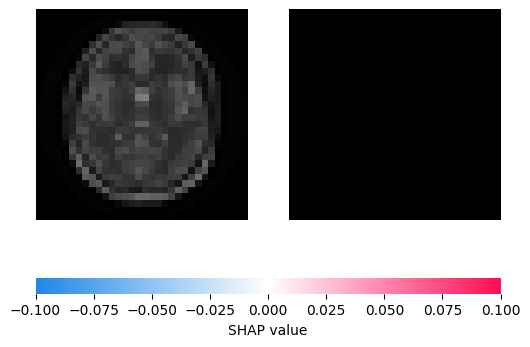

In [1]:
# Complete VGG16-based Image Classification with SHAP Integration

# Step 1: Install necessary libraries
!pip install tensorflow
!pip install shap
!pip install matplotlib

# Step 2: Import libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from google.colab import files
import io
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import shap

# Step 3: Upload files
print("Please upload your dataset (images) in any format.")
uploaded = files.upload()

# Step 4: Load and preprocess data
def load_data(uploaded_files):
    image_list = []
    label_list = []

    for filename in uploaded_files.keys():
        try:
            img = Image.open(io.BytesIO(uploaded_files[filename]))
            img = img.convert("RGB")  # Ensure the image is in RGB format
            img = img.resize((32, 32))  # Resize to match VGG16 input size
            img_array = np.array(img) / 255.0  # Normalize the image
            image_list.append(img_array)
            label_list.append(filename)  # Use the filename as the label
        except Exception as e:
            print(f"Error loading {filename}: {e}")

    return np.array(image_list), np.array(label_list)

# Load the dataset
x_data, y_data = load_data(uploaded)

# Check the number of samples
print(f"Number of samples loaded: {len(x_data)}")

# Ensure there are enough samples
if len(x_data) == 0:
    raise ValueError("No images were loaded. Please upload valid image files.")

# Convert labels to categorical if there are enough samples
if len(x_data) > 1:
    class_names = np.unique(y_data)
    y_data = pd.get_dummies(y_data).values  # One-hot encoding
else:
    print("Not enough samples to create a validation set. Using all data for training.")
    class_names = np.unique(y_data)
    y_data = pd.get_dummies(y_data).values  # One-hot encoding for single sample

# Ensure the input shape is correct
if len(x_data.shape) == 3:  # If there's only one image, add a channel dimension
    x_data = np.expand_dims(x_data, axis=0)  # Shape becomes (1, 32, 32, 3)

# Step 5: Build the model
def build_model():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base_model.trainable = False  # Freeze the base model

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(len(class_names), activation='softmax')  # Number of classes
    ])

    return model

model = build_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 6: Train the model
if len(x_data) > 1:
    model.fit(x_data, y_data, epochs=10, batch_size=32, validation_split=0.2)
else:
    model.fit(x_data, y_data, epochs=10, batch_size=1)  # Train with a single sample

# Step 7: Evaluate the model
test_loss, test_acc = model.evaluate(x_data, y_data)
print(f'Test accuracy: {test_acc}')

# Step 8: SHAP integration for explainability
def explain_model(model, x_data):
    explainer = shap.GradientExplainer(model, x_data)  # Use GradientExplainer for deep learning models
    shap_values = explainer.shap_values(x_data)

    # Visualize the SHAP values for the first image
    shap.image_plot(shap_values, x_data)

# Call the explain_model function to visualize SHAP values
explain_model(model, x_data)